# CIFAR-10 -- Ablation Study (Architecture)

This notebook performs a systematic ablation study to understand how different architectural and regularization choices affect CNN performance on CIFAR‑10.
Rather than searching for the highest possible accuracy, the goal is to isolate the contribution of each component and build a principled, well‑justified final architecture.

To achieve this, we follow three guiding principles:

1. Modify one dimension at a time (depth, width, activation, regularization, optimizer).  
2. Start from simple baselines and progressively increase complexity.  
3. Prefer interpretability and stability over marginal accuracy gains.  

The final architecture selected here will serve as the foundation for the fully‑augmented training in Notebook 3.

## 1 - Librairies

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import os

SEED=42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

## 2 - Data Loading & Preprocessing

### 2.1 - Load Data :

In [ ]:
(data_train, data_test, data_val), infos = tfds.load(
    'cifar10',
    split=[
        'train[:48000]',              # 80%
        'train[48000:]+test[:4000]',  # 10%
        'test[4000:]'                 # 10%
    ],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully.")

### 2.2 - Preprocessing Pipeline :

In [ ]:
# Preprocessing Layer -> Resize + Rescale
resize_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(32, 32),
    tf.keras.layers.Rescaling(1.0 / 255)
])

# Preprocessing Functions
def preprocess(dataset):

    dataset = dataset.shuffle(buffer_size=1000,seed=SEED)

    # Resize + rescale
    dataset = dataset.map(
        lambda x, y: (resize_rescale(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Batch + prefetch
    dataset = dataset.batch(64)
    return dataset.prefetch(tf.data.AUTOTUNE)

# Create Preprocessed Datasets
batch_train = preprocess(data_train)
batch_val   = preprocess(data_val)
batch_test  = preprocess(data_test)

## 3 - Callbacks & Creation function :

In [ ]:
def get_callbacks(name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"checkpoints/{name}.weights.h5",
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=True,
            mode="max"
        )
    ]

In [ ]:
def create_cnn(
    input_shape=(32, 32, 3),
    blocks=[32],                 # e.g. [32], [32,64], [32,64,128]
    dropout_block=0.0,           # dropout after each block
    activation='relu',
    optimizer='adamw',
    weight_decay=0.004,          # Default weight_decay
    lr=0.001,
    padding='same',
    seed=SEED
):
    tf.random.set_seed(seed)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=input_shape))

    # Convolutional blocks
    for filters in blocks:
        model.add(tf.keras.layers.Conv2D(filters, 3, activation=activation, padding=padding))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Conv2D(filters, 3, activation=activation, padding=padding))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.MaxPool2D())
        if dropout_block > 0:
            model.add(tf.keras.layers.Dropout(dropout_block))

    # Global pooling
    model.add(tf.keras.layers.GlobalAveragePooling2D())

    # Output layer
    model.add(tf.keras.layers.Dense(10))
    model.add(tf.keras.layers.Activation('softmax', dtype=tf.float32))

    # Optimizer
    if optimizer == 'adamw':
        opt = tf.keras.optimizers.AdamW(weight_decay=weight_decay)
    elif optimizer == 'adam':
        opt = tf.keras.optimizers.Adam()

    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=opt,
        metrics=['accuracy']
    )

    return model

## 4 - Architecture Scaling

Why study architecture first?

Before tuning regularization or optimization, we must determine the model’s capacity.
Depth and width directly control the expressiveness of the network, and their effect is often larger than that of hyperparameters.

This section answers three key questions:

- How many convolutional blocks are necessary?
- Does increasing the number of filters improve generalization?
- Do different activation functions change convergence behavior?

Each experiment modifies only one architectural dimension at a time and start from the best result found in previous section.

### 4.1 - Experiment A : Depth (number of blocks)

We begin by studying the effect of depth while keeping the width constant.
Increasing depth allows the model to extract more hierarchical features, but also increases optimization difficulty and the risk of overfitting.

Our hypothesis:

> “Going from one to several blocks should improve performance, but gains will saturate beyond a certain depth.”




In [ ]:
# Two blocks (32 filters fixated)
model_2_blocks = create_cnn(blocks=[32, 32])
# model_2_blocks.summary() # Not necessary
history_2_blocks = model_2_blocks.fit(batch_train,
                                      epochs=30,
                                      validation_data=batch_val,
                                      verbose=2,
                                      callbacks=get_callbacks("model_2_blocks"))

Epoch 1/30
750/750 - 13s - 17ms/step - accuracy: 0.4908 - loss: 1.4159 - val_accuracy: 0.5393 - val_loss: 1.2556 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 7s - 9ms/step - accuracy: 0.6224 - loss: 1.0744 - val_accuracy: 0.4502 - val_loss: 1.6896 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 9s - 12ms/step - accuracy: 0.6652 - loss: 0.9483 - val_accuracy: 0.6308 - val_loss: 1.0433 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 6s - 7ms/step - accuracy: 0.6981 - loss: 0.8687 - val_accuracy: 0.6317 - val_loss: 1.0464 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 8s - 10ms/step - accuracy: 0.7159 - loss: 0.8160 - val_accuracy: 0.6648 - val_loss: 0.9607 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 11s - 15ms/step - accuracy: 0.7302 - loss: 0.7710 - val_accuracy: 0.6527 - val_loss: 0.9902 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 6s - 8ms/step - accuracy: 0.7434 - loss: 0.7370 - val_accuracy: 0.6705 - val_loss: 0.9387 - learning_rate: 1.0000e-03
Epoch 8/30
750/750 - 

In [ ]:
# Three blocks (32 filters fixated)
model_3_blocks = create_cnn(blocks=[32, 32, 32])
# model_3_blocks.summary() # Not necessary
history_3_blocks = model_3_blocks.fit(batch_train,
                                      epochs=30,
                                      validation_data=batch_val,
                                      verbose=2,
                                      callbacks=get_callbacks("model_3_blocks"))

Epoch 1/30
750/750 - 15s - 20ms/step - accuracy: 0.5312 - loss: 1.3130 - val_accuracy: 0.4535 - val_loss: 1.5512 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 7s - 9ms/step - accuracy: 0.6709 - loss: 0.9343 - val_accuracy: 0.5980 - val_loss: 1.1307 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 6s - 8ms/step - accuracy: 0.7214 - loss: 0.7970 - val_accuracy: 0.5112 - val_loss: 1.7007 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 10s - 13ms/step - accuracy: 0.7524 - loss: 0.7106 - val_accuracy: 0.6772 - val_loss: 0.9687 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 6s - 8ms/step - accuracy: 0.7768 - loss: 0.6471 - val_accuracy: 0.7190 - val_loss: 0.8237 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 11s - 14ms/step - accuracy: 0.7951 - loss: 0.5932 - val_accuracy: 0.7277 - val_loss: 0.8217 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 9s - 12ms/step - accuracy: 0.8062 - loss: 0.5580 - val_accuracy: 0.7430 - val_loss: 0.7514 - learning_rate: 1.0000e-03
Epoch 8/30
750/750 -

In [ ]:
# Four blocks (32 filters fixated)
model_4_blocks = create_cnn(blocks=[32, 32, 32, 32])
# model_4_blocks.summary() # Not necessary
history_4_blocks = model_4_blocks.fit(batch_train,
                                      epochs=30,
                                      validation_data=batch_val,
                                      verbose=2,
                                      callbacks=get_callbacks("model_4_blocks"))

Epoch 1/30
750/750 - 19s - 26ms/step - accuracy: 0.5259 - loss: 1.3116 - val_accuracy: 0.4605 - val_loss: 1.6866 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 6s - 9ms/step - accuracy: 0.6816 - loss: 0.9000 - val_accuracy: 0.6695 - val_loss: 0.9616 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 7s - 10ms/step - accuracy: 0.7343 - loss: 0.7566 - val_accuracy: 0.6848 - val_loss: 0.9464 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 6s - 8ms/step - accuracy: 0.7671 - loss: 0.6714 - val_accuracy: 0.7387 - val_loss: 0.7644 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 7s - 10ms/step - accuracy: 0.7885 - loss: 0.6052 - val_accuracy: 0.6842 - val_loss: 0.9842 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 10s - 13ms/step - accuracy: 0.8064 - loss: 0.5550 - val_accuracy: 0.7230 - val_loss: 0.8177 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 6s - 8ms/step - accuracy: 0.8547 - loss: 0.4218 - val_accuracy: 0.7880 - val_loss: 0.6125 - learning_rate: 2.0000e-04
Epoch 8/30
750/750 - 

In [ ]:
print("Accuracy with 2 blocks:", model_2_blocks.evaluate(batch_test)[1])
print("Accuracy with 3 blocks:", model_3_blocks.evaluate(batch_test)[1])
print("Accuracy with 4 blocks:", model_4_blocks.evaluate(batch_test)[1])

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7753 - loss: 0.6497
Accuracy with 2 blocks: 0.7696666717529297
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8033 - loss: 0.5813
Accuracy with 3 blocks: 0.8038333058357239
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8082 - loss: 0.5783
Accuracy with 4 blocks: 0.8051666617393494


<Axes: title={'center': 'Loss: 2 vs 3 vs 4 Blocks'}>

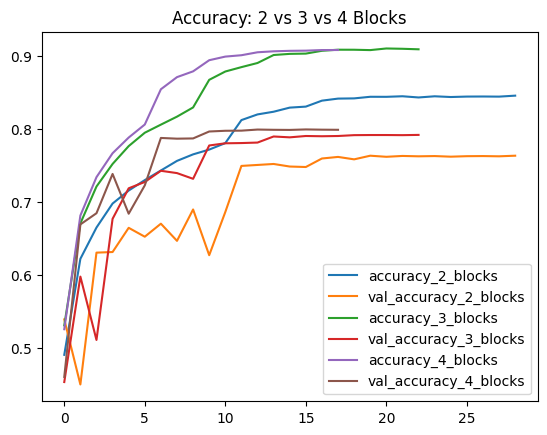

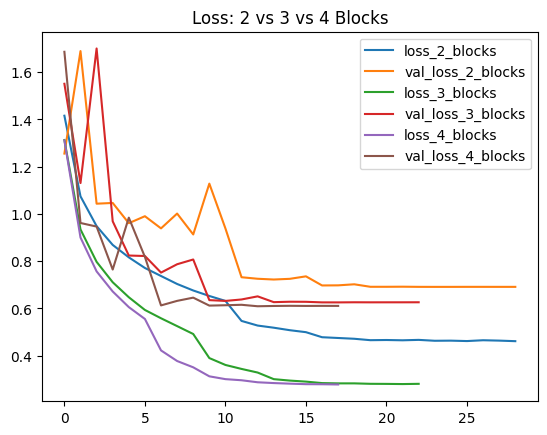

In [ ]:
# Plot curves :

df_2_blocks = pd.DataFrame(history_2_blocks.history).drop(columns=['learning_rate'])
df_2_blocks.columns = ['accuracy_2_blocks', 'loss_2_blocks', 'val_accuracy_2_blocks', 'val_loss_2_blocks']
df_2_acc = df_2_blocks[['accuracy_2_blocks','val_accuracy_2_blocks']]
df_2_loss = df_2_blocks[['loss_2_blocks','val_loss_2_blocks']]

df_3_blocks = pd.DataFrame(history_3_blocks.history).drop(columns=['learning_rate'])
df_3_blocks.columns = ['accuracy_3_blocks', 'loss_3_blocks', 'val_accuracy_3_blocks', 'val_loss_3_blocks']
df_3_acc = df_3_blocks[['accuracy_3_blocks','val_accuracy_3_blocks']]
df_3_loss = df_3_blocks[['loss_3_blocks','val_loss_3_blocks']]

df_4_blocks = pd.DataFrame(history_4_blocks.history).drop(columns=['learning_rate'])
df_4_blocks.columns = ['accuracy_4_blocks', 'loss_4_blocks', 'val_accuracy_4_blocks', 'val_loss_4_blocks']
df_4_acc = df_4_blocks[['accuracy_4_blocks','val_accuracy_4_blocks']]
df_4_loss = df_4_blocks[['loss_4_blocks','val_loss_4_blocks']]

pd.concat([df_2_acc,
           df_3_acc,
           df_4_acc], axis=1
          ).plot(title="Accuracy: 2 vs 3 vs 4 Blocks")

pd.concat([df_2_loss,
           df_3_loss,
           df_4_loss], axis=1
          ).plot(title="Loss: 2 vs 3 vs 4 Blocks")

#### Conclusion — Depth

Increasing depth from two to three convolutional blocks improves validation accuracy and reduces loss, confirming that additional hierarchical feature extraction benefits CIFAR‑10.
However, adding a fourth block does not yield further gains and increase the complexity of the model.

**Three blocks** therefore offer the best trade‑off between expressiveness, optimization stability, and computational cost.

### 4.2 - Experiment B : Width (Filters)

We found that the optimal depth is 3, we now explore width.
Increasing the number of filters increases representational capacity, especially in deeper layers where features become more abstract.

Our hypothesis:

> “A progressive increase in filters (e.g., 32 → 64 → 128) should outperform uniform configurations.”


In [ ]:
# 32 - 32 - 64
model_A = create_cnn(blocks=[32, 32, 64])
# model_A.summary() # Not necessary
history_A = model_A.fit(batch_train,
                        epochs=30,
                        validation_data=batch_val,
                        verbose=2,
                        callbacks=get_callbacks("model_A"))

Epoch 1/30
750/750 - 20s - 27ms/step - accuracy: 0.5444 - loss: 1.2613 - val_accuracy: 0.5867 - val_loss: 1.1416 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 7s - 9ms/step - accuracy: 0.6922 - loss: 0.8749 - val_accuracy: 0.6317 - val_loss: 1.0650 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 7s - 9ms/step - accuracy: 0.7509 - loss: 0.7209 - val_accuracy: 0.7035 - val_loss: 0.8781 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 9s - 13ms/step - accuracy: 0.7828 - loss: 0.6274 - val_accuracy: 0.7213 - val_loss: 0.8016 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 7s - 10ms/step - accuracy: 0.8075 - loss: 0.5606 - val_accuracy: 0.7132 - val_loss: 0.8839 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 10s - 13ms/step - accuracy: 0.8267 - loss: 0.4980 - val_accuracy: 0.7680 - val_loss: 0.6948 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 10s - 13ms/step - accuracy: 0.8455 - loss: 0.4456 - val_accuracy: 0.7355 - val_loss: 0.7848 - learning_rate: 1.0000e-03
Epoch 8/30
750/750 

In [ ]:
# 32 - 64 - 128
model_B = create_cnn(blocks=[32, 64, 128])
# model_B.summary() # Not necessary
history_B = model_B.fit(batch_train,
                        epochs=30,
                        validation_data=batch_val,
                        verbose=2,
                        callbacks=get_callbacks("model_B"))

Epoch 1/30
750/750 - 21s - 27ms/step - accuracy: 0.5999 - loss: 1.1230 - val_accuracy: 0.6568 - val_loss: 0.9673 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 8s - 10ms/step - accuracy: 0.7453 - loss: 0.7313 - val_accuracy: 0.6780 - val_loss: 0.9318 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 12s - 16ms/step - accuracy: 0.8032 - loss: 0.5708 - val_accuracy: 0.7462 - val_loss: 0.7548 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 9s - 12ms/step - accuracy: 0.8377 - loss: 0.4694 - val_accuracy: 0.7637 - val_loss: 0.7210 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 8s - 11ms/step - accuracy: 0.8690 - loss: 0.3789 - val_accuracy: 0.7753 - val_loss: 0.6651 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 8s - 10ms/step - accuracy: 0.8941 - loss: 0.3068 - val_accuracy: 0.8000 - val_loss: 0.5989 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 10s - 14ms/step - accuracy: 0.9186 - loss: 0.2385 - val_accuracy: 0.7572 - val_loss: 0.8558 - learning_rate: 1.0000e-03
Epoch 8/30
750/75

In [ ]:
print("Accuracy with 32-32-32 filters:", model_3_blocks.evaluate(batch_test)[1])
print("Accuracy with 32-32-64 filters:", model_A.evaluate(batch_test)[1])
print("Accuracy with 32-64-128 filters:", model_B.evaluate(batch_test)[1])

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8044 - loss: 0.5726
Accuracy with 32-32-32 filters: 0.8038333058357239
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8051 - loss: 0.5666
Accuracy with 32-32-64 filters: 0.812333345413208
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8487 - loss: 0.4821
Accuracy with 32-64-128 filters: 0.8500000238418579


<Axes: title={'center': 'Loss: 32-32-32 vs 32-32-64 vs 32-64-128 filters'}>

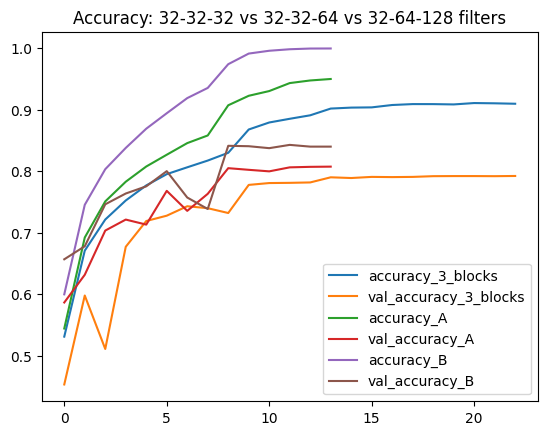

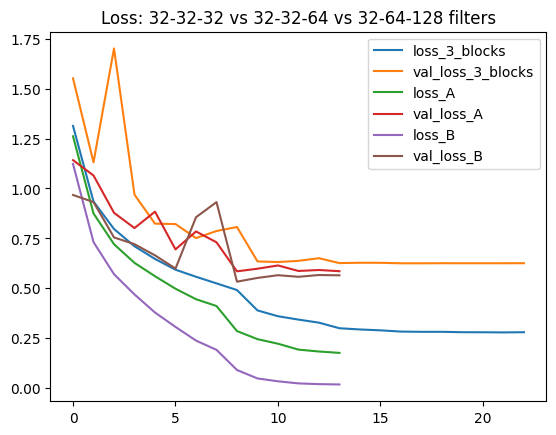

In [ ]:
# Plot curves :

df_A = pd.DataFrame(history_A.history).drop(columns=['learning_rate'])
df_A.columns = ['accuracy_A', 'loss_A', 'val_accuracy_A', 'val_loss_A']
df_A_acc = df_A[['accuracy_A','val_accuracy_A']]
df_A_loss = df_A[['loss_A','val_loss_A']]

df_B = pd.DataFrame(history_B.history).drop(columns=['learning_rate'])
df_B.columns = ['accuracy_B', 'loss_B', 'val_accuracy_B', 'val_loss_B']
df_B_acc = df_B[['accuracy_B','val_accuracy_B']]
df_B_loss = df_B[['loss_B','val_loss_B']]

pd.concat([df_3_acc,
           df_A_acc,
           df_B_acc], axis=1
          ).plot(title="Accuracy: 32-32-32 vs 32-32-64 vs 32-64-128 filters")

pd.concat([df_3_loss,
           df_A_loss,
           df_B_loss], axis=1
          ).plot(title="Loss: 32-32-32 vs 32-32-64 vs 32-64-128 filters")

#### Conclusion — Width

Once depth is fixed, widening the network improves generalization.
A modest increase (32‑32‑64) provides small gains, while a progressive configuration (32‑64‑128) achieves the best validation performance and the most stable convergence.
This confirms that increasing capacity in deeper layers is more effective than uniformly wide architectures.

We retain **32‑64‑128** as the optimal width configuration.

### 4.3 - Experiment C : Activation Functions

ReLU is the standard activation for CNNs, but variants like LeakyReLU can mitigate the “dying ReLU” problem and improve gradient flow.
We compare both to evaluate whether the variant provides meaningful benefits on this architecture.

Our hypothesis:

> “LeakyReLU may offer slightly smoother convergence, but differences will likely remain small.”

In [ ]:
# 32 - 64 - 128 & Leaky ReLU
model_leaky = create_cnn(blocks=[32, 64, 128], activation='leaky_relu')
# model_leaky.summary() # Not necessary
history_leaky = model_leaky.fit(batch_train,
                        epochs=30,
                        validation_data=batch_val,
                        verbose=2,
                        callbacks=get_callbacks("model_leaky"))

Epoch 1/30
750/750 - 20s - 27ms/step - accuracy: 0.5680 - loss: 1.2154 - val_accuracy: 0.4938 - val_loss: 1.4801 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 13s - 18ms/step - accuracy: 0.7148 - loss: 0.8241 - val_accuracy: 0.6880 - val_loss: 0.9028 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 9s - 12ms/step - accuracy: 0.7691 - loss: 0.6665 - val_accuracy: 0.7533 - val_loss: 0.7177 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 10s - 13ms/step - accuracy: 0.8069 - loss: 0.5649 - val_accuracy: 0.7445 - val_loss: 0.7536 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 8s - 11ms/step - accuracy: 0.8328 - loss: 0.4900 - val_accuracy: 0.7587 - val_loss: 0.7073 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 8s - 10ms/step - accuracy: 0.8534 - loss: 0.4301 - val_accuracy: 0.7490 - val_loss: 0.7350 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 8s - 10ms/step - accuracy: 0.8740 - loss: 0.3714 - val_accuracy: 0.7905 - val_loss: 0.6228 - learning_rate: 1.0000e-03
Epoch 8/30
750/75

In [ ]:
print("Accuracy with ReLU", model_B.evaluate(batch_test)[1])
print("Accuracy with Leaky ReLU:", model_leaky.evaluate(batch_test)[1])

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8471 - loss: 0.4768
Accuracy with ReLU 0.8500000238418579
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8534 - loss: 0.4558
Accuracy with Leaky ReLU: 0.8533333539962769


<Axes: title={'center': 'Loss: ReLU vs Leaky ReLU'}>

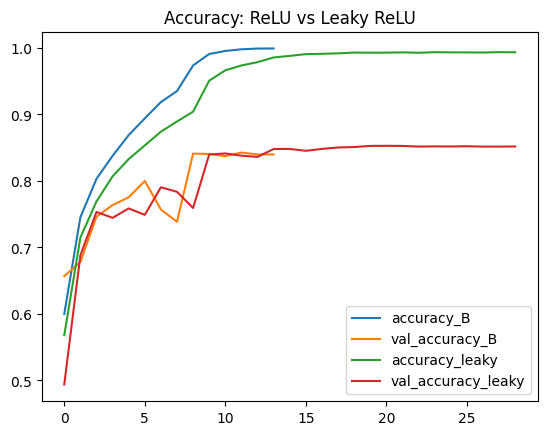

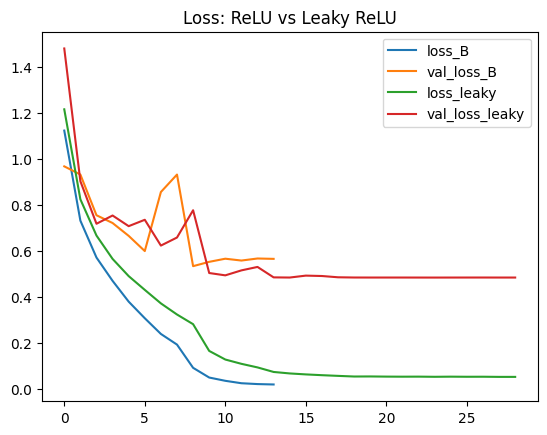

In [ ]:
# Plot curves :

df_leaky = pd.DataFrame(history_leaky.history).drop(columns=['learning_rate'])
df_leaky.columns = ['accuracy_leaky', 'loss_leaky', 'val_accuracy_leaky', 'val_loss_leaky']
df_leaky_acc = df_leaky[['accuracy_leaky','val_accuracy_leaky']]
df_leaky_loss = df_leaky[['loss_leaky','val_loss_leaky']]

pd.concat([df_B_acc,
           df_leaky_acc],
          axis=1).plot(title="Accuracy: ReLU vs Leaky ReLU")

pd.concat([df_B_loss,
           df_leaky_loss],
          axis=1).plot(title="Loss: ReLU vs Leaky ReLU")

#### Conclusion — Activation

ReLU and LeakyReLU achieve very similar accuracy on this architecture.
LeakyReLU produces slightly smoother validation curves and marginally lower validation loss, likely due to its ability to mitigate the dying ReLU problem.

Although the improvement is small, we keep **LeakyReLU** as the activation function for the remaining experiments.

## 5 - Regularization

### Regularization Experiments

With the architecture fixed, we now address overfitting.
Regularization is essential for medium‑capacity CNNs on CIFAR‑10, and we focus on two complementary techniques:

- Dropout, which introduces stochastic noise in activations
- Weight decay, which constrains the magnitude of the weights

Each method is evaluated independently to understand its specific contribution.

### 5.1 - Dropout

Dropout is widely used in CNNs to reduce co‑adaptation between features.
We test a standard value of 0.2, commonly effective for CIFAR‑10, to evaluate its impact on stability and generalization.

Our hypothesis:

> “Dropout should reduce overfitting and stabilize validation curves.”

In [ ]:
# 32 - 64 - 128 & Leaky ReLU & Dropout(0.2)
model_dropout = create_cnn(blocks=[32, 64, 128],
                           activation='leaky_relu',
                           dropout_block=0.2)

# model_dropout.summary() # Not necessary
history_dropout = model_dropout.fit(batch_train,
                        epochs=30,
                        validation_data=batch_val,
                        verbose=2,
                        callbacks=get_callbacks("model_dropout"))

Epoch 1/30
750/750 - 20s - 27ms/step - accuracy: 0.5388 - loss: 1.2877 - val_accuracy: 0.6487 - val_loss: 1.0069 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 8s - 10ms/step - accuracy: 0.6710 - loss: 0.9333 - val_accuracy: 0.6958 - val_loss: 0.8669 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 8s - 11ms/step - accuracy: 0.7250 - loss: 0.7884 - val_accuracy: 0.7355 - val_loss: 0.7742 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 7s - 10ms/step - accuracy: 0.7576 - loss: 0.7009 - val_accuracy: 0.7307 - val_loss: 0.7985 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 8s - 10ms/step - accuracy: 0.7797 - loss: 0.6350 - val_accuracy: 0.7665 - val_loss: 0.7008 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 8s - 10ms/step - accuracy: 0.7988 - loss: 0.5812 - val_accuracy: 0.7362 - val_loss: 0.7932 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 7s - 10ms/step - accuracy: 0.8091 - loss: 0.5495 - val_accuracy: 0.7948 - val_loss: 0.6141 - learning_rate: 1.0000e-03
Epoch 8/30
750/750 

In [ ]:
print('Accuracy without dropout:', model_leaky.evaluate(batch_test)[1])
print('Accuracy with dropout:', model_dropout.evaluate(batch_test)[1])

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8528 - loss: 0.4586
Accuracy without dropout: 0.8533333539962769
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8738 - loss: 0.3663
Accuracy with dropout: 0.871833324432373


<Axes: title={'center': 'Loss: No dropout vs Dropout(0.2)'}>

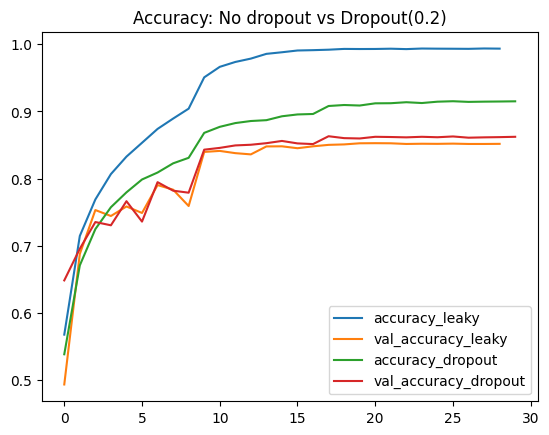

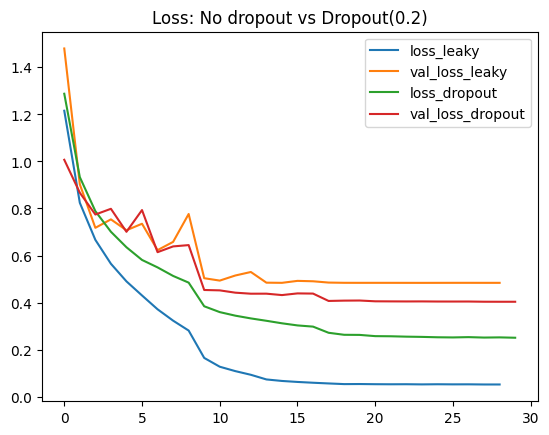

In [ ]:
# Plot curves :

df_dropout = pd.DataFrame(history_dropout.history).drop(columns=['learning_rate'])
df_dropout.columns = ['accuracy_dropout', 'loss_dropout', 'val_accuracy_dropout', 'val_loss_dropout']
df_dropout_acc = df_dropout[['accuracy_dropout','val_accuracy_dropout']]
df_dropout_loss = df_dropout[['loss_dropout','val_loss_dropout']]

pd.concat([df_leaky_acc,
           df_dropout_acc],
          axis=1).plot(title="Accuracy: No dropout vs Dropout(0.2)")

pd.concat([df_leaky_loss,
           df_dropout_loss],
          axis=1).plot(title="Loss: No dropout vs Dropout(0.2)")


#### Conclusion — Dropout

Introducing dropout (0.2) significantly stabilizes training, reduces overfitting, and improves validation loss without harming accuracy.
The effect is consistent across epochs, confirming that dropout is an effective regularization method for this architecture.

We therefore keep **Dropout (0.2)** in all subsequent experiments.

### 5.2 - Weight Decay (AdamW)

Weight decay is a key regularization mechanism in AdamW.
We test several values to find the balance between under‑regularization (overfitting) and over‑regularization (capacity loss).

Our hypothesis:

> “Moderate values (around 0.001) should provide the best trade‑off.”

In [ ]:
model_wd_small = create_cnn(blocks=[32,64,128],
                            activation='leaky_relu',
                            dropout_block=0.2,
                            weight_decay=0.0005)
# model_wd_small.summary() # Not necessary
model_wd_small_history = model_wd_small.fit(batch_train,
                                            epochs=30,
                                            validation_data=batch_train,
                                            verbose=2,
                                            callbacks=get_callbacks("model_wd_small"))

Epoch 1/30
750/750 - 32s - 43ms/step - accuracy: 0.5404 - loss: 1.2810 - val_accuracy: 0.4522 - val_loss: 1.6810 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 18s - 24ms/step - accuracy: 0.6700 - loss: 0.9392 - val_accuracy: 0.6587 - val_loss: 0.9650 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 15s - 20ms/step - accuracy: 0.7184 - loss: 0.8013 - val_accuracy: 0.7441 - val_loss: 0.7273 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 18s - 25ms/step - accuracy: 0.7527 - loss: 0.7086 - val_accuracy: 0.7637 - val_loss: 0.6839 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 16s - 21ms/step - accuracy: 0.7766 - loss: 0.6423 - val_accuracy: 0.7685 - val_loss: 0.6789 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 15s - 20ms/step - accuracy: 0.7957 - loss: 0.5932 - val_accuracy: 0.7482 - val_loss: 0.7137 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 15s - 21ms/step - accuracy: 0.8114 - loss: 0.5470 - val_accuracy: 0.8173 - val_loss: 0.5249 - learning_rate: 1.0000e-03
Epoch 8/30
75

In [ ]:
model_wd_mid = create_cnn(blocks=[32,64,128],
                            activation='leaky_relu',
                            dropout_block=0.2,
                            weight_decay=0.001)
# model_wd_mid.summary() # Not necessary
model_wd_mid_history = model_wd_mid.fit(batch_train,
                                            epochs=30,
                                            validation_data=batch_train,
                                            verbose=2,
                                            callbacks=get_callbacks("model_wd_mid"))

Epoch 1/30
750/750 - 27s - 36ms/step - accuracy: 0.5415 - loss: 1.2892 - val_accuracy: 0.6413 - val_loss: 1.0367 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 13s - 18ms/step - accuracy: 0.6759 - loss: 0.9228 - val_accuracy: 0.6727 - val_loss: 0.9414 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 25s - 34ms/step - accuracy: 0.7288 - loss: 0.7800 - val_accuracy: 0.6926 - val_loss: 0.8819 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 12s - 16ms/step - accuracy: 0.7593 - loss: 0.6907 - val_accuracy: 0.7239 - val_loss: 0.7966 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 13s - 18ms/step - accuracy: 0.7824 - loss: 0.6295 - val_accuracy: 0.7887 - val_loss: 0.5997 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 13s - 18ms/step - accuracy: 0.7988 - loss: 0.5830 - val_accuracy: 0.7559 - val_loss: 0.6855 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 16s - 21ms/step - accuracy: 0.8134 - loss: 0.5417 - val_accuracy: 0.8292 - val_loss: 0.4871 - learning_rate: 1.0000e-03
Epoch 8/30
75

In [ ]:
model_wd_high = create_cnn(blocks=[32,64,128],
                            activation='leaky_relu',
                            dropout_block=0.2,
                            weight_decay=0.005)
# model_wd_high.summary() # Not necessary
model_wd_high_history = model_wd_high.fit(batch_train,
                                            epochs=30,
                                            validation_data=batch_train,
                                            verbose=2,
                                            callbacks=get_callbacks("model_wd_high"))


Epoch 1/30
750/750 - 23s - 31ms/step - accuracy: 0.5363 - loss: 1.2954 - val_accuracy: 0.5284 - val_loss: 1.3591 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 12s - 16ms/step - accuracy: 0.6732 - loss: 0.9331 - val_accuracy: 0.7019 - val_loss: 0.8483 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 12s - 16ms/step - accuracy: 0.7284 - loss: 0.7838 - val_accuracy: 0.7438 - val_loss: 0.7337 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 11s - 15ms/step - accuracy: 0.7590 - loss: 0.6929 - val_accuracy: 0.7617 - val_loss: 0.6942 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 11s - 15ms/step - accuracy: 0.7807 - loss: 0.6290 - val_accuracy: 0.8188 - val_loss: 0.5308 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 11s - 15ms/step - accuracy: 0.7987 - loss: 0.5843 - val_accuracy: 0.8100 - val_loss: 0.5417 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 11s - 15ms/step - accuracy: 0.8114 - loss: 0.5471 - val_accuracy: 0.8477 - val_loss: 0.4473 - learning_rate: 1.0000e-03
Epoch 8/30
75

In [ ]:
print('Weight decay 0.0005:', model_wd_small.evaluate(batch_test)[1])
print('Weight decay 0.001:', model_wd_mid.evaluate(batch_test)[1])
print('Weight decay 0.004 (Default for tf):', model_dropout.evaluate(batch_test)[1])
print('Weight decay 0.005:', model_wd_high.evaluate(batch_test)[1])

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8711 - loss: 0.3919
Weight decay 0.0005: 0.8738333582878113
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8782 - loss: 0.3865
Weight decay 0.001: 0.8794999718666077
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8687 - loss: 0.3854
Weight decay 0.004 (Default for tf): 0.871833324432373
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8616 - loss: 0.4120
Weight decay 0.005: 0.8569999933242798


<Axes: title={'center': 'Loss: Weight Decay 0.0005 vs 0.001 vs 0.004(default) vs 0.005'}>

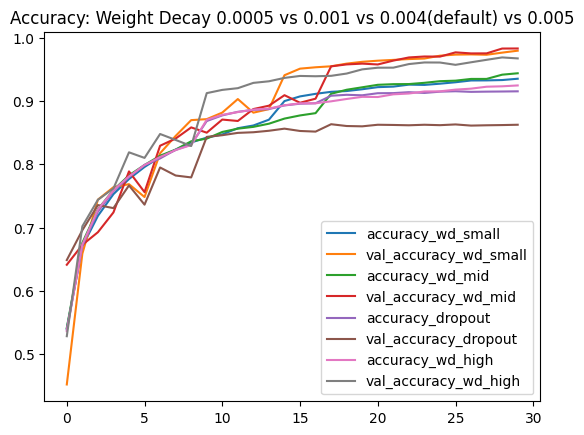

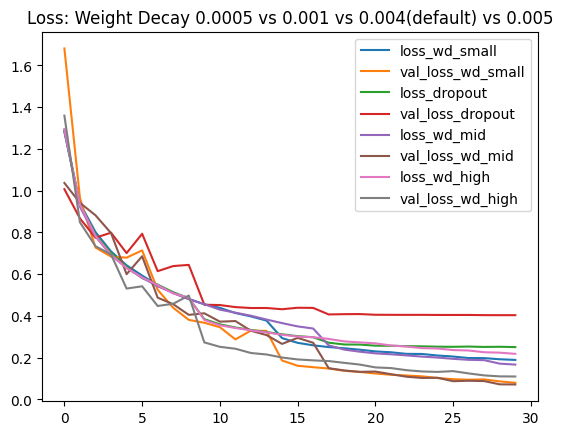

In [ ]:
# Plot curves

df_wd_small=pd.DataFrame(model_wd_small_history.history).drop(columns=['learning_rate'])
df_wd_small.columns=['accuracy_wd_small','loss_wd_small','val_accuracy_wd_small','val_loss_wd_small']
df_wd_small_acc=df_wd_small[['accuracy_wd_small','val_accuracy_wd_small']]
df_wd_small_loss=df_wd_small[['loss_wd_small','val_loss_wd_small']]

df_wd_mid=pd.DataFrame(model_wd_mid_history.history).drop(columns=['learning_rate'])
df_wd_mid.columns=['accuracy_wd_mid','loss_wd_mid','val_accuracy_wd_mid','val_loss_wd_mid']
df_wd_mid_acc=df_wd_mid[['accuracy_wd_mid','val_accuracy_wd_mid']]
df_wd_mid_loss=df_wd_mid[['loss_wd_mid','val_loss_wd_mid']]

df_wd_high=pd.DataFrame(model_wd_high_history.history).drop(columns=['learning_rate'])
df_wd_high.columns=['accuracy_wd_high','loss_wd_high','val_accuracy_wd_high','val_loss_wd_high']
df_wd_high_acc=df_wd_high[['accuracy_wd_high','val_accuracy_wd_high']]
df_wd_high_loss=df_wd_high[['loss_wd_high','val_loss_wd_high']]

pd.concat([df_wd_small_acc,
           df_wd_mid_acc,
           df_dropout_acc,
           df_wd_high_acc],
          axis=1).plot(title="Accuracy: Weight Decay 0.0005 vs 0.001 vs 0.004(default) vs 0.005")

pd.concat([df_wd_small_loss,
           df_wd_mid_loss,
           df_dropout_loss,
           df_wd_high_loss],
          axis=1).plot(title="Loss: Weight Decay 0.0005 vs 0.001 vs 0.004(default) vs 0.005")

#### Conclusion — Weight Decay

Among the tested values, 0.001 provides the best validation and test performance.
Lower values (0.0005) under‑regularize the model, while higher values (0.004 and 0.005) overly constrain the weights and degrade generalization.

**Weight decay = 0.001** offers the optimal balance between stability and capacity and is retained for the final architecture.

## 6 - Optimizers

Finally, we compare Adam and AdamW on the optimized architecture.
While both optimizers often reach similar accuracy, AdamW decouples weight decay from the gradient update, which can improve stability.

Our hypothesis:

> “AdamW should produce smoother validation curves and more stable convergence.”


In [ ]:
model_adam = create_cnn(blocks=[32,64,128],
                        activation='leaky_relu',
                        dropout_block=0.2,
                        optimizer='adam')
# model_adam.summary() # Not necessary
model_adam_history = model_adam.fit(batch_train,
                                    epochs=30,
                                    validation_data=batch_train,
                                    verbose=2,
                                    callbacks=get_callbacks("model_adam"))

Epoch 1/30
750/750 - 22s - 30ms/step - accuracy: 0.5396 - loss: 1.2906 - val_accuracy: 0.5467 - val_loss: 1.3732 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 12s - 16ms/step - accuracy: 0.6648 - loss: 0.9537 - val_accuracy: 0.6909 - val_loss: 0.8694 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 20s - 27ms/step - accuracy: 0.7182 - loss: 0.8052 - val_accuracy: 0.7017 - val_loss: 0.8379 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 11s - 15ms/step - accuracy: 0.7553 - loss: 0.7075 - val_accuracy: 0.7779 - val_loss: 0.6516 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 21s - 27ms/step - accuracy: 0.7754 - loss: 0.6418 - val_accuracy: 0.7254 - val_loss: 0.8106 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 21s - 28ms/step - accuracy: 0.7971 - loss: 0.5905 - val_accuracy: 0.8163 - val_loss: 0.5194 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 12s - 16ms/step - accuracy: 0.8119 - loss: 0.5448 - val_accuracy: 0.7842 - val_loss: 0.6108 - learning_rate: 1.0000e-03
Epoch 8/30
75

In [ ]:
print('AdamW Weight decay 0.001:', model_wd_mid.evaluate(batch_test)[1])
print('Adam:', model_adam.evaluate(batch_test)[1])

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8776 - loss: 0.3839
AdamW Weight decay 0.001: 0.8794999718666077
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8767 - loss: 0.3839
Adam: 0.875166654586792


<Axes: title={'center': 'Loss: Best AdamW vs Adam'}>

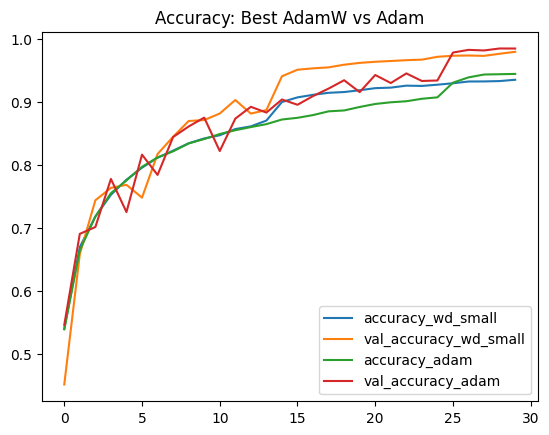

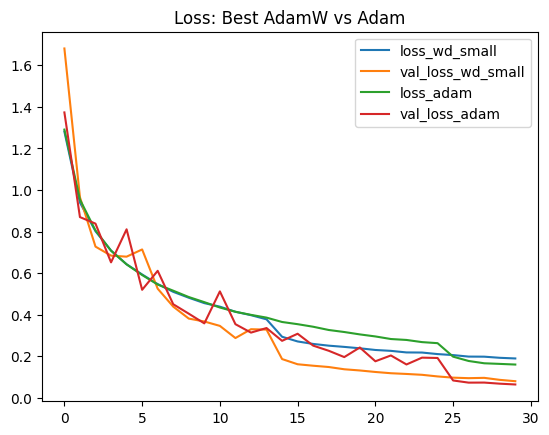

In [ ]:
# Plot curves

df_adam=pd.DataFrame(model_adam_history.history).drop(columns=['learning_rate'])
df_adam.columns=['accuracy_adam','loss_adam','val_accuracy_adam','val_loss_adam']
df_adam_acc=df_adam[['accuracy_adam','val_accuracy_adam']]
df_adam_loss=df_adam[['loss_adam','val_loss_adam']]

pd.concat([df_wd_small_acc,
           df_adam_acc],
          axis=1).plot(title="Accuracy: Best AdamW vs Adam")

pd.concat([df_wd_small_loss,
           df_adam_loss],
          axis=1).plot(title="Loss: Best AdamW vs Adam")

#### Conclusion — Optimizers

Adam and AdamW reach similar final accuracy on this architecture.
However, AdamW produces noticeably smoother validation curves and more stable convergence, confirming the benefit of decoupled weight decay when regularization is important.

Given its stability and compatibility with weight decay tuning, we keep **AdamW** as the final optimizer.

## 7 - Summary

This ablation study reveals the relative importance of each architectural and regularization choice:

- **Depth:** 3 blocks provide the best trade‑off between expressiveness and simplicity.

- **Width:** A progressive configuration (32‑64‑128) significantly improves generalization.

- **Activation:** LeakyReLU offers slightly smoother convergence but similar accuracy to ReLU.

- **Dropout:** 0.2 stabilizes training and reduces overfitting.

- **Weight Decay:** 0.001 is the optimal value for AdamW.

- **Optimizer:** AdamW and Adam reach similar accuracy, but AdamW converges more smoothly.

The final architecture selected for Notebook 3 is:

> **3 blocks — 32‑64‑128 filters — LeakyReLU — Dropout (0.2) — AdamW (wd=0.001)**

This model provides a strong, stable foundation for the final training phase with data augmentation.